In [ ]:
import geopandas as gpd
import geodatasets as gds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
import shapely as shp

In [2]:
model1 = pd.read_csv('Models/Model_1/Model_1_TestData.csv')
model2 = pd.read_csv('Models/Model_2/Model_2_TestData.csv')
model3 = pd.read_csv('Models/Model_3/Model_3_TestData.csv')
model4 = pd.read_csv('Models/Model_4/Model_4_TestData.csv')


In [3]:
# Convert Julian Day Sin to Julian Day
def undoJulianDaySin(values):
    return np.ceil((np.arcsin(values) / np.pi + 0.5) * 365).astype(int)

In [4]:
model1['day_of_year'] = model1['JulianDay_Sin'].apply(undoJulianDaySin)
model2['day_of_year'] = model2['JulianDay_Sin'].apply(undoJulianDaySin)
model3['day_of_year'] = model3['JulianDay_Sin'].apply(undoJulianDaySin)
model4['day_of_year'] = model4['JulianDay_Sin'].apply(undoJulianDaySin)

In [5]:
model1

,Lat,Lon,Alt,Temp,Precip,Year,JulianDay_Sin,O18 A,H2 A,O18 P,H2 P,day_of_year
0,46.491434,9.898181,1724.0,6.623712,4.920363,1999.0,0.296713,-8.25,-57.00,-10.298080,-77.509529,218
1,22.316667,114.166667,66.0,29.100000,455.500000,2010.0,-0.213521,-8.17,-52.10,-7.769792,-55.710220,158
2,43.732389,7.423583,2.0,19.000000,372.000000,2000.0,-0.711657,-6.50,-45.00,-5.876551,-38.945137,91
3,45.320000,-75.670000,114.0,17.800000,130.000000,2017.0,0.296713,-8.20,-58.00,-7.692731,-54.785782,218
4,-0.841111,29.941944,1595.0,24.926385,4.519369,2005.0,-0.958718,-1.69,3.20,-1.408673,0.746347,34
...,...,...,...,...,...,...,...,...,...,...,...,...
18834,48.828100,9.200000,314.0,1.600000,29.900000,2008.0,-0.271958,-14.64,-112.35,-11.133422,-84.795341,151
18835,0.453056,33.195000,1181.0,21.978937,0.000000,2003.0,-0.288482,-3.80,-22.30,-0.069452,12.361563,149
18836,32.366667,-6.400000,468.0,11.800000,4.500000,2003.0,0.085965,-0.39,6.07,-4.020002,-22.865509,193
18837,41.270000,69.270000,428.0,12.000000,40.000000,1971.0,-0.723644,-5.00,-26.00,-8.576833,-62.496880,89


In [6]:
model1['Date'] = pd.to_datetime(model1['Year'].astype(int).astype(str) + '-' + model1['day_of_year'].astype(str), format='%Y-%j')
model2['Date'] = pd.to_datetime(model2['Year'].astype(int).astype(str) + '-' + model2['day_of_year'].astype(str), format='%Y-%j')
model3['Date'] = pd.to_datetime(model3['Year'].astype(int).astype(str) + '-' + model3['day_of_year'].astype(str), format='%Y-%j')
model4['Date'] = pd.to_datetime(model4['Year'].astype(int).astype(str) + '-' + model4['day_of_year'].astype(str), format='%Y-%j')

In [7]:
model1Geo = gpd.GeoDataFrame(model1, geometry=gpd.points_from_xy(model1['Lon'], model1['Lat']), crs='EPSG:4326')
model2Geo = gpd.GeoDataFrame(model2, geometry=gpd.points_from_xy(model2['Lon'], model2['Lat']), crs='EPSG:4326')
model3Geo = gpd.GeoDataFrame(model3, geometry=gpd.points_from_xy(model3['Lon'], model3['Lat']), crs='EPSG:4326')
model4Geo = gpd.GeoDataFrame(model4, geometry=gpd.points_from_xy(model4['Lon'], model4['Lat']), crs='EPSG:4326')

In [8]:
world = gpd.read_file(gds.get_path("naturalearth.land"))

In [23]:
lowDataPoint = shp.geometry.Point(100, 50)
highDataPoint = shp.geometry.Point(7.6, 47.5)

# Find the closest point in each model to the low and high data points
ilowClose = model1Geo.distance(lowDataPoint).idxmin()
ihighClose = model1Geo.distance(highDataPoint).idxmin()

C:\Users\jaxgr\AppData\Local\Temp\ipykernel_18184\2558732142.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ilowClose = model1Geo.distance(lowDataPoint).idxmin()
C:\Users\jaxgr\AppData\Local\Temp\ipykernel_18184\2558732142.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ihighClose = model1Geo.distance(highDataPoint).idxmin()


In [28]:
# Gather lat and lon of the closest points
lowLat = model1Geo.loc[ilowClose, 'Lat']
lowLon = model1Geo.loc[ilowClose, 'Lon']
highLat = model1Geo.loc[ihighClose, 'Lat']
highLon = model1Geo.loc[ihighClose, 'Lon']

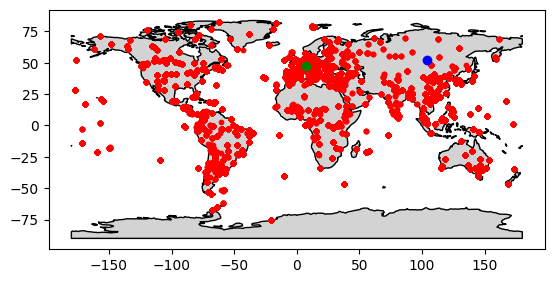

In [24]:
fig, ax = plt.subplots()
world.plot(ax=ax, color='lightgrey', edgecolor='black')
model1Geo.plot(ax=ax, color='red', markersize=10, label='Model 1')
ax.scatter(model1Geo.loc[ilowClose, 'Lon'], model1Geo.loc[ilowClose, 'Lat'], color='blue',  label='Low Data Point')
ax.scatter(model1Geo.loc[ihighClose, 'Lon'], model1Geo.loc[ihighClose, 'Lat'], color='green',  label='High Data Point')

In [ ]:
m1High = model1[(model1['Lon'] == highLon) & (model1['Lat'] == highLat)]
m1Low = model1[(model1['Lon'] == lowLon) & (model1['Lat'] == lowLat)]
m2High = model2[(model2['Lon'] == highLon) & (model2['Lat'] == highLat)]
m2Low = model2[(model2['Lon'] == lowLon) & (model2['Lat'] == lowLat)]
m3High = model3[(model3['Lon'] == highLon) & (model3['Lat'] == highLat)]
m3Low = model3[(model3['Lon'] == lowLon) & (model3['Lat'] == lowLat)]
m4High = model4[(model4['Lon'] == highLon) & (model4['Lat'] == highLat)]
m4Low = model4[(model4['Lon'] == lowLon) & (model4['Lat'] == lowLat)]

High Data Point

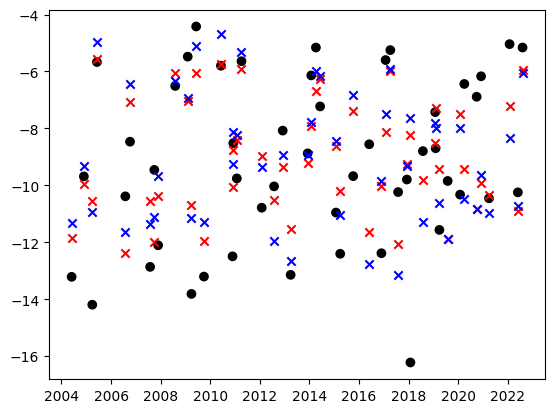

In [52]:
fig, ax = plt.subplots()
# Plot time series of global model high point
ax.scatter(m1High['Date'], m1High['O18 A'], label='Model 1 High Point', color='black', linestyle='')
ax.scatter(m1High['Date'], m1High['O18 P'], label='Model 1 High Point', color='red', marker='x')
ax.scatter(m2High['Date'], m2High['O18 P'], label='Model 2 High Point', color='blue', marker='x')

Low Data Point

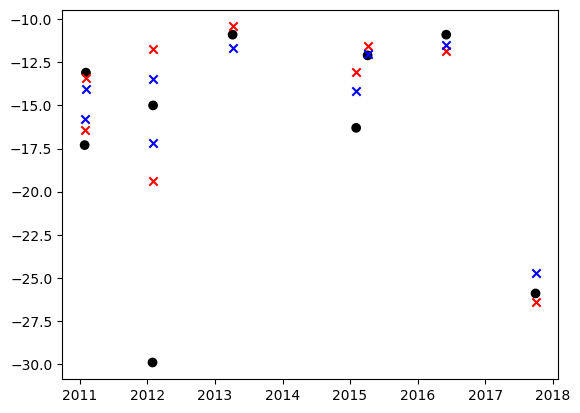

In [53]:
fig, ax = plt.subplots()
# Plot time series of global model low point
ax.scatter(m1Low['Date'], m1Low['O18 A'], label='Model 1 Low Point', color='black', linestyle='')
ax.scatter(m1Low['Date'], m1Low['O18 P'], label='Model 1 Low Point', color='red', marker='x')
ax.scatter(m2Low['Date'], m2Low['O18 P'], label='Model 2 Low Point', color='blue', marker='x')